# PHẦN 1: CHUẨN BỊ VÀ LÀM SẠCH DỮ LIỆU

In [27]:
# ============================================
# PHẦN 1: CHUẨN BỊ VÀ LÀM SẠCH DỮ LIỆU
# ============================================
# 1. Chuẩn bị thư viên và dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Dữ liệu đã qua bước tiền xử lý trong PostgreSQL: lọc riêng nhóm game, loại các cột không nhất quán, và tổng hợp thành game_master ở cấp độ 1 dòng/game.  
Phần này kiểm tra lại chất lượng dữ liệu trước khi phân tích.

In [28]:
# Import file csv data
gm = pd.read_csv('sql_preprocessing_data/game_master.csv')
monet = pd.read_csv('sql_preprocessing_data/monetization_f.csv')
regional = pd.read_csv('sql_preprocessing_data/regional_usage_f.csv')

## Uncomment để import preprocessing data thông qua postgres sql sever của docker
"""
import psycopg2
conn = psycopg2.connect(
    host='localhost',
    port=5432,
    dbname='game_db',
    user='postgres',
    password='abcde'
)
gm = pd.read_sql('select * from game_master', conn)
monet = pd.read_sql('select * from monetization_f', conn)
"""

print(gm.shape, monet.shape, regional.shape)
gm.head()

(14686, 39) (34168, 12) (17035, 12)


,app_id,app_name,monetization_type,installs,content_rating,release_date,app_size_mb,average_rating,editor_choice,total_revenue,...,avg_review_rating,positive_rate,negative_rate,avg_helpful_votes,n_crashes,severe_crash_rate,crash_resolved_rate,has_crash_data,installs_num,size_tier
0,APP_000974,ProTracker,Free,416,Everyone,2022-07-19,1511.4,4.3,f,2.23,...,4.200000,0.583333,0.000000,1.250000,4,0.0,1.0,1,416,Long-tail
1,APP_001571,GoCalc,Free,61048,Teen,2020-05-22,3711.7,3.5,f,261.36,...,3.580000,0.400000,0.133333,1.333333,2,0.0,0.5,1,61048,Mid
2,APP_002315,BrowserLink,Free with Ads,893886,Everyone,2022-07-21,709.4,2.1,f,12193.40,...,2.344444,0.000000,0.444444,1.777778,3,0.0,0.0,1,893886,Top
3,APP_005738,ScannerZone,Free,120081,Everyone,2020-06-08,3193.0,4.2,f,69.91,...,3.826667,0.333333,0.133333,1.933333,2,0.5,1.0,1,120081,Top
4,APP_006504,UltraCalc,Free,14393,Teen,2024-03-23,3961.8,4.1,f,131.01,...,4.425000,0.750000,0.000000,1.916667,1,1.0,0.0,1,14393,Mid


In [29]:
# 2. Khảo sát dữ liệu
print(f"Bảng game_master có {gm.shape[0]} dòng/bản ghi và {gm.shape[1]} cột.")
gm.info()

Bảng game_master có 14686 dòng/bản ghi và 39 cột.
<class 'pandas.DataFrame'>
RangeIndex: 14686 entries, 0 to 14685
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   app_id                 14686 non-null  str    
 1   app_name               14686 non-null  str    
 2   monetization_type      14686 non-null  str    
 3   installs               14686 non-null  int64  
 4   content_rating         14686 non-null  str    
 5   release_date           14686 non-null  str    
 6   app_size_mb            14686 non-null  float64
 7   average_rating         14686 non-null  float64
 8   editor_choice          14686 non-null  str    
 9   total_revenue          14686 non-null  float64
 10  avg_revenue_per_month  14686 non-null  float64
 11  avg_arpu               14686 non-null  float64
 12  avg_ltv                14686 non-null  float64
 13  avg_conversion_rate    14686 non-null  float64
 14  total_ad_revenu

app_id                   0
app_name                 0
monetization_type        0
installs                 0
content_rating           0
release_date             0
app_size_mb              0
average_rating           0
editor_choice            0
total_revenue            0
avg_revenue_per_month    0
avg_arpu                 0
avg_ltv                  0
avg_conversion_rate      0
total_ad_revenue         0
total_ad_impressions     0
total_sub_users          0
n_months                 0
n_users                  0
n_sessions               0
avg_session_duration     0
avg_daily_usage          0
avg_clicks               0
avg_scrolls              0
avg_screen_views         0
avg_retention_days       0
uninstall_rate           0
notif_click_rate         0
n_reviews                0
avg_review_rating        0
positive_rate            0
negative_rate            0
avg_helpful_votes        0
n_crashes                0
severe_crash_rate        0
crash_resolved_rate      0
has_crash_data           0
i

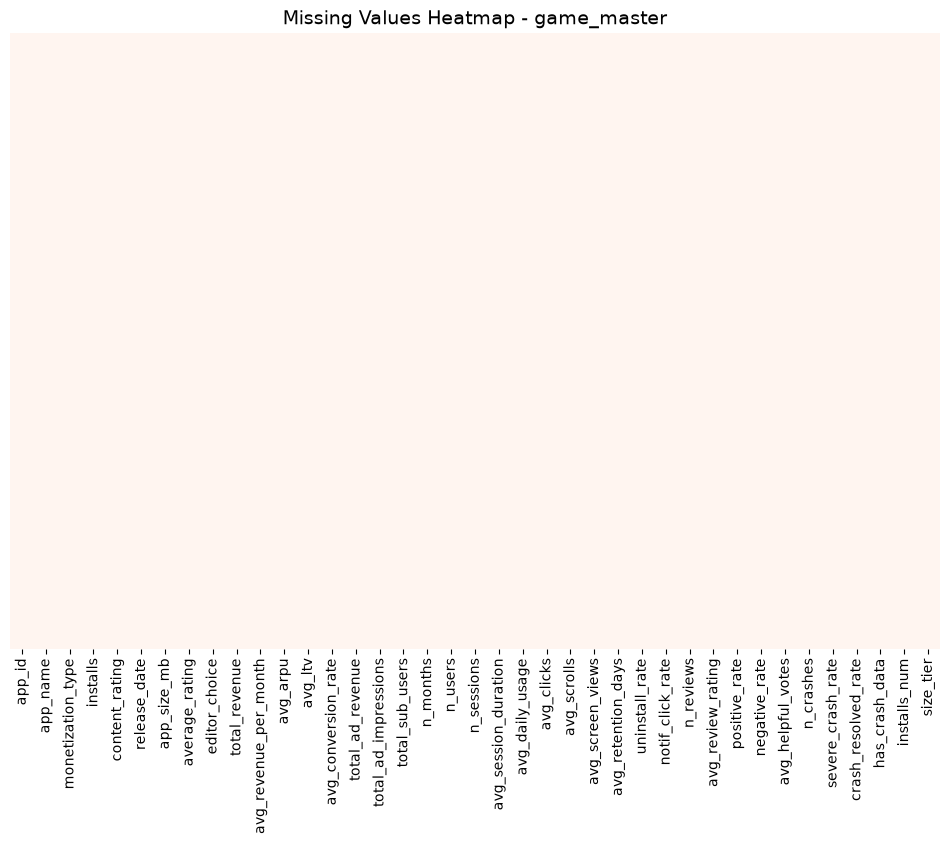

In [30]:
# 3. Kiểm tra null và trùng lặp
print(gm.isnull().sum())
print(f"\nSố dòng trùng lặp: {gm.duplicated().sum()}")
print(f"Số app_id duy nhất: {gm['app_id'].nunique()} / {len(gm)} dòng")

# Trực quan hóa các giá trị null
plt.figure(figsize=(12, 8))
sns.heatmap(gm.isnull(), cbar=False, cmap="Reds", yticklabels=False)
plt.title("Missing Values Heatmap - game_master", fontsize=14)
plt.show()

Không có giá trị null và không có dòng trùng lặp. Mỗi app_id xuất hiện đúng một lần, xác nhận game_master đã được tổng hợp đúng ở cấp độ game.

In [31]:
# 4. Thống kê mô tả
gm.describe()

,installs,app_size_mb,average_rating,total_revenue,avg_revenue_per_month,avg_arpu,avg_ltv,avg_conversion_rate,total_ad_revenue,total_ad_impressions,...,n_reviews,avg_review_rating,positive_rate,negative_rate,avg_helpful_votes,n_crashes,severe_crash_rate,crash_resolved_rate,has_crash_data,installs_num
count,1.468600e+04,14686.000000,14686.000000,1.468600e+04,1.468600e+04,14686.000000,14686.000000,14686.000000,1.468600e+04,1.468600e+04,...,14686.000000,14686.000000,14686.000000,14686.000000,14686.000000,14686.000000,14686.000000,14686.000000,14686.000000,1.468600e+04
mean,1.711575e+06,2114.688404,3.598958,2.105421e+06,1.026384e+06,0.567627,4.230412,3.135775,1.154683e+05,4.270087e+05,...,15.012733,3.545264,0.273216,0.200572,2.525029,1.986382,0.299922,0.521760,0.864020,1.711575e+06
std,2.276720e+07,1094.828134,0.893693,4.834854e+07,3.074701e+07,0.987997,7.731460,4.322123,5.834997e+06,1.087267e+07,...,3.853891,0.826755,0.211019,0.187911,0.796190,1.402398,0.357643,0.401874,0.342779,2.276720e+07
min,1.000000e+01,200.100000,1.000000,1.000000e-02,6.666667e-03,0.000100,0.000000,0.000000,0.000000e+00,0.000000e+00,...,3.000000,1.033333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+01
25%,2.943000e+03,1167.275000,3.000000,1.391225e+02,7.370750e+01,0.003550,0.030000,0.000000,0.000000e+00,0.000000e+00,...,12.000000,2.986667,0.076923,0.000000,1.956975,1.000000,0.000000,0.000000,1.000000,2.943000e+03
50%,2.198600e+04,2123.100000,3.700000,2.365350e+03,1.202935e+03,0.028900,0.260000,0.000000,0.000000e+00,0.000000e+00,...,15.000000,3.637500,0.250000,0.153846,2.465476,2.000000,0.125000,0.500000,1.000000,2.198600e+04
75%,1.573490e+05,3057.275000,4.300000,4.486063e+04,2.168299e+04,0.493900,3.870000,6.803333,4.938125e+02,6.412750e+03,...,18.000000,4.212500,0.437500,0.333333,3.000000,3.000000,0.500000,1.000000,1.000000,1.573490e+05
max,1.777618e+09,3999.500000,5.000000,3.197999e+09,3.197999e+09,6.774400,72.320000,15.000000,6.771042e+08,1.132997e+09,...,34.000000,4.990909,0.933333,1.000000,7.300000,11.000000,1.000000,1.000000,1.000000,1.777618e+09


C:\Users\hh\AppData\Local\Temp\ipykernel_21904\2663153523.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis[i].boxplot(gm_num[col], vert=False)
C:\Users\hh\AppData\Local\Temp\ipykernel_21904\2663153523.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis[i].boxplot(gm_num[col], vert=False)
C:\Users\hh\AppData\Local\Temp\ipykernel_21904\2663153523.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis[i].boxplot(gm_num[col], vert=False)
C:\Users\hh\AppData\Local\Temp\ipykernel_21904\2663153523.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horiz

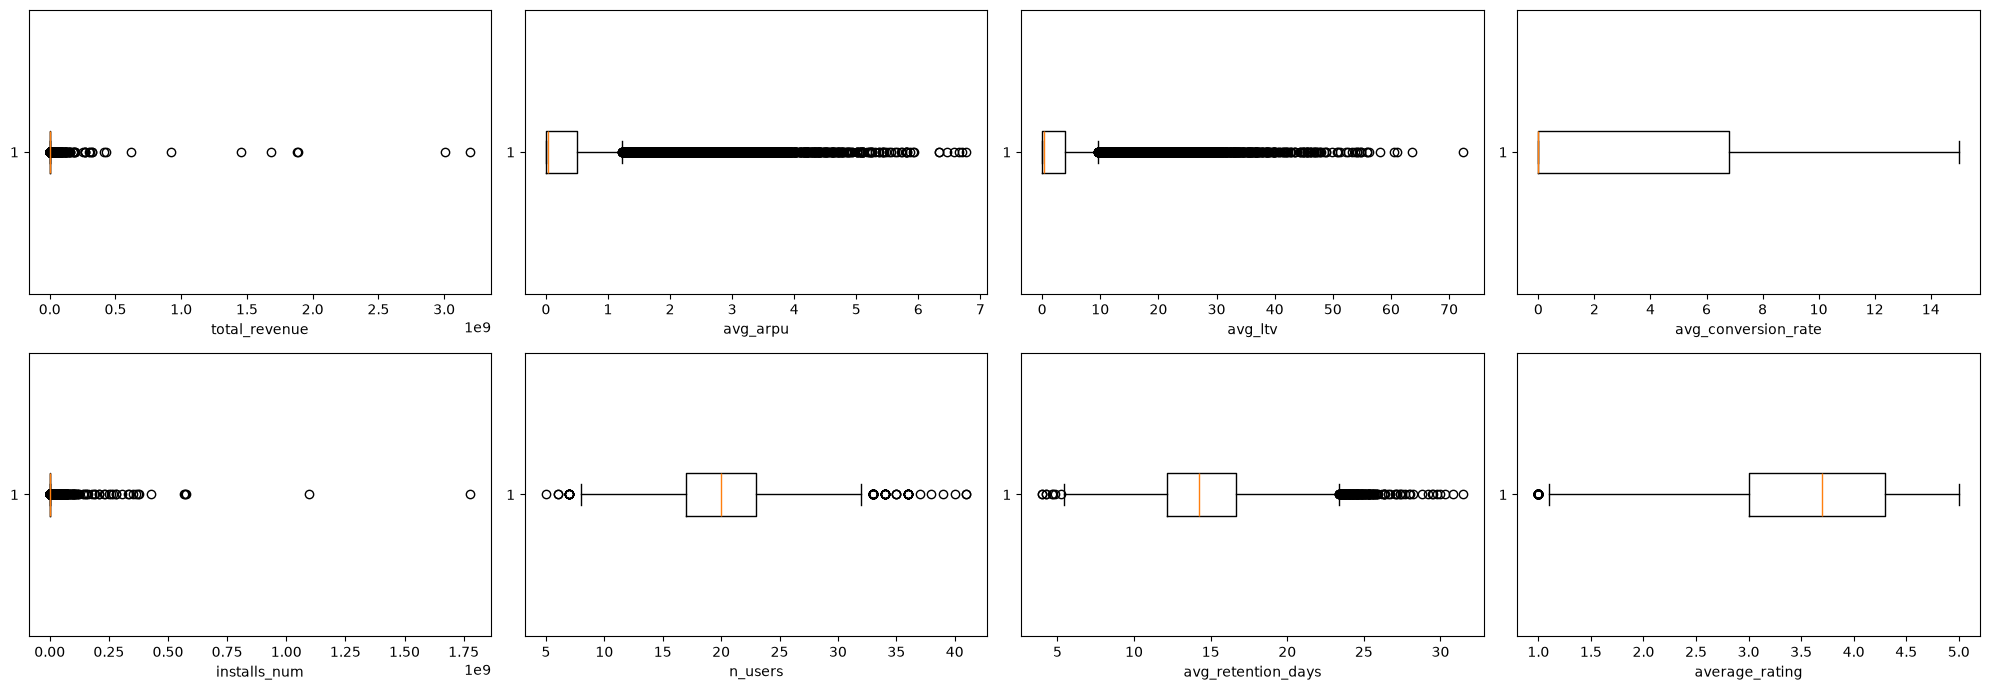

In [32]:
# 5. Xử lý outliers
# Lấy các cột số quan trọng
gm_num = gm[["total_revenue", "avg_arpu", "avg_ltv", "avg_conversion_rate", "installs_num", "n_users", "avg_retention_days", "average_rating"]]

# Boxplot trước khi xử lý
fig, axis = plt.subplots(2, 4, figsize=(20, 7))
axis = axis.flatten()

for i, col in enumerate(gm_num.columns):
    axis[i].boxplot(gm_num[col], vert=False)
    axis[i].set_xlabel(col)
plt.tight_layout()
plt.show()

In [33]:
# Kiểm tra số lượng outlier theo chuẩn 1.5*IQR
print("BẢNG THỐNG KÊ SỐ LƯỢNG OUTLIER (THEO CHUẨN 1.5 * IQR):\n")

for col in gm_num:
    Q1 = gm_num[col].quantile(0.25)
    Q3 = gm_num[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = gm_num[(gm_num[col] < lower_bound) | (gm_num[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / len(gm_num)) * 100

    print(f"{col:<22}: {count:>5} dòng ({percentage:.2f}% trên tổng data)")

BẢNG THỐNG KÊ SỐ LƯỢNG OUTLIER (THEO CHUẨN 1.5 * IQR):

total_revenue         :  2713 dòng (18.47% trên tổng data)
avg_arpu              :  2644 dòng (18.00% trên tổng data)
avg_ltv               :  2391 dòng (16.28% trên tổng data)
avg_conversion_rate   :     0 dòng (0.00% trên tổng data)
installs_num          :  2451 dòng (16.69% trên tổng data)
n_users               :    78 dòng (0.53% trên tổng data)
avg_retention_days    :   180 dòng (1.23% trên tổng data)
average_rating        :    61 dòng (0.42% trên tổng data)


# PHẦN 2: EDA1 - SO SÁNH GIỮA CÁC MÔ HÌNH MONETIZATION

Câu hỏi: Mô hình kiếm tiền nào hiệu quả nhất trên thị trường, và phù hợp với game ở quy mô nào?

In [34]:
# ============================================
# PHẦN 2: EDA1 - SO SÁNH GIỮA CÁC MÔ HÌNH MONETIZATION
# ============================================

# 1. Đánh giá doanh thu, ARPU, LTV, Conversion theo 5 mô hình
# 1.1 Doanh thu
# tổng doanh thu và số game theo từng mô hình
summary_rev = gm.groupby('monetization_type').agg(n_games=('app_id', 'count'), total_revenue=('total_revenue', 'sum'), total_ad_revenue=('total_ad_revenue', 'sum')
).reset_index()

# tính % share
summary_rev['revenue_share_pct'] = summary_rev['total_revenue'] / summary_rev['total_revenue'].sum() * 100
summary_rev['game_share_pct'] = summary_rev['n_games'] / summary_rev['n_games'].sum() * 100
summary_rev['ad_share_pct'] = summary_rev['total_ad_revenue'] / summary_rev['total_revenue'] * 100

summary_rev = summary_rev.sort_values('total_revenue', ascending=False)
summary_rev

,monetization_type,n_games,total_revenue,total_ad_revenue,revenue_share_pct,game_share_pct,ad_share_pct
4,Subscription,2168,1.349039e+10,0.000000e+00,43.629678,14.762359,0.000000
3,Paid,1458,1.216861e+10,0.000000e+00,39.354861,9.927822,0.000000
2,Freemium,3735,5.068032e+09,1.654058e+09,16.390678,25.432385,32.637097
1,Free with Ads,2953,1.450418e+08,4.170955e+07,0.469084,20.107585,28.756921
0,Free,4372,4.814242e+07,0.000000e+00,0.155699,29.769849,0.000000


In [35]:
# vẽ cơ cấu doanh thu
def h_color(values, high="#08519c", low="#a4caee", other="#1994db"):
    return [high if v == values.max() else low if v == values.min() else other for v in values]

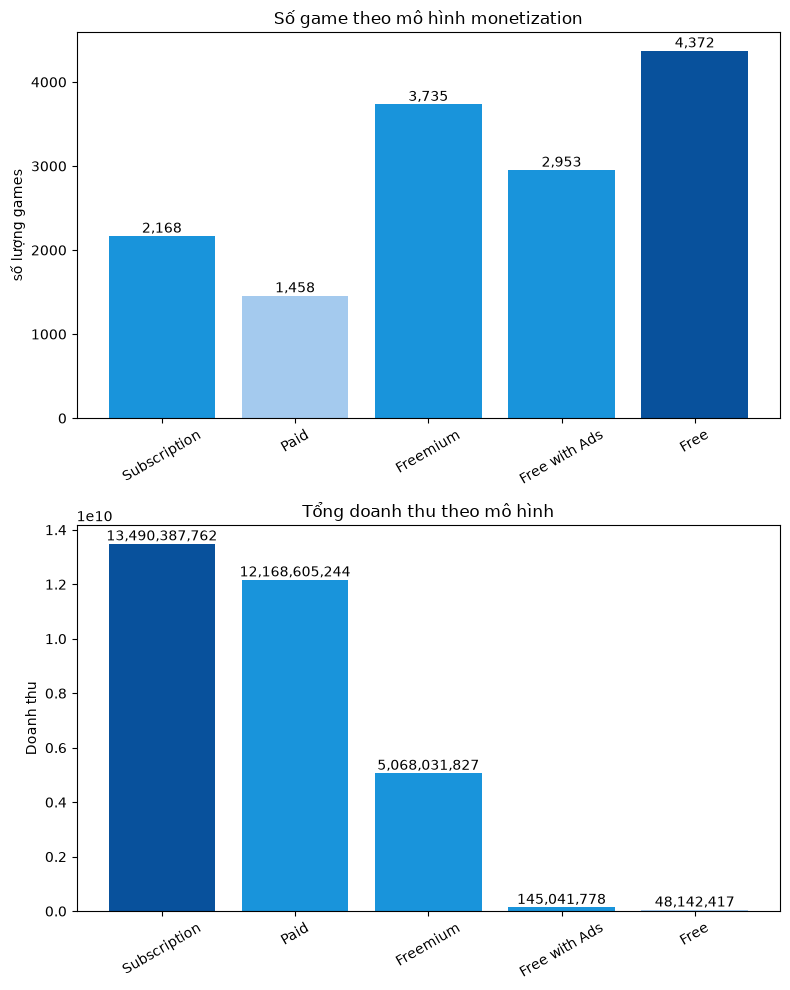

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# số game theo mô hình
axes[0].bar(summary_rev['monetization_type'], summary_rev['n_games'], color=h_color(summary_rev['n_games']))
axes[0].set_title('Số game theo mô hình monetization')
axes[0].set_ylabel('số lượng games')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(summary_rev['n_games']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# doanh thu theo mô hình
axes[1].bar(summary_rev['monetization_type'], summary_rev['total_revenue'], color=h_color(summary_rev['total_revenue']))
axes[1].set_title('Tổng doanh thu theo mô hình')
axes[1].set_ylabel('Doanh thu')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(summary_rev['total_revenue'],0):
    axes[1].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Subscription và Paid chỉ chiếm 24.7% số game nhưng tạo ra 83% tổng doanh thu. Ngược lại, Free và Free with ads chiếm đến gần 50% số game nhưng chỉ đóng góp 0,5% doanh thu - 1 con số rất ít. Kể cả Freemium dù chiểm 1/4 số game nhưng cũng chỉ đóng góp 16% doanh thu.  
=> Điều này cho thấy mô hình thu tiền trực tiếp vượt trội về hiệu quả doanh thu so với các mô hình còn lại.

In [37]:
# 1.2. ARPU
# tính ARPU theo nhóm (vì user base cố định theo app nên suy ngược từ total_revenue/arpu)

# tính user base cho từng dòng trong monetization_f
monet2 = monet[monet['arpu_usd'] > 0].copy()
monet2['user_base'] = monet2['total_revenue_usd'] / monet2['arpu_usd']

# gộp theo mô hình: sum(revenue)/sum(users), không dùng AVG(arpu) vì sự trùng lặp các dòng không thể phân biệt trong bảng monetization, số bản ghi không phản ánh hết arpu
arpu_by_model = monet2.groupby('monetization_type').apply(lambda x: pd.Series({
    'total_revenue': x['total_revenue_usd'].sum(),
    'total_users': x['user_base'].sum(),
    'arpu_weighted': x['total_revenue_usd'].sum() / x['user_base'].sum(),
    'arpu_simple_avg': x['arpu_usd'].mean()   # để so sánh, thấy khác biệt
    })
).reset_index()
arpu_by_model

,monetization_type,total_revenue,total_users,arpu_weighted,arpu_simple_avg
0,Free,4.814242e+07,1.895046e+10,0.002540,0.002552
1,Free with Ads,1.450418e+08,8.978668e+09,0.016154,0.015516
2,Freemium,5.068032e+09,1.555508e+10,0.325812,0.278408
3,Paid,1.216861e+10,4.495692e+09,2.706726,2.752995
4,Subscription,1.349039e+10,8.301951e+09,1.624966,1.488032


ARPU phân tầng rõ theo mức độ trực tiếp thu tiền: Free (0.0025) => Free with Ads (0.016) => Freemium (0.33) => Subscription (1.62) => Paid (2.71). Chênh lệch giữa cao nhất và thấp nhất hơn 1,000 lần, một lần nữa khẳng định hiệu quả tạo ra doanh thu của các mô hình trả tiền trực tiếp.  

Hai cách tính ARPU (arpu_weighted dùng cách tính thủ công SUM/SUM và arpu_simple_avg dùng hàm trung bình cộng thông thường) cho kết quả gần nhau ở đây, do user base phân tán tương đối đều. Tuy nhiên ta vẫn dùng cách weighted vì đúng về mặt phương pháp.

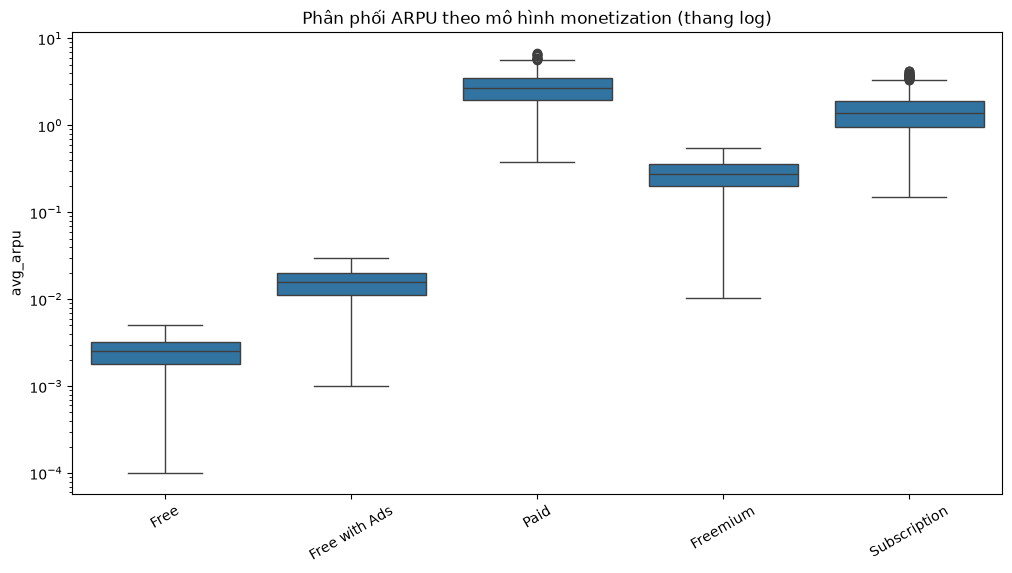

In [38]:
# phân phối ARPU giữa các mô hình (dùng thang log vì Free ~0.05 còn Paid ~6.9 (chênh hơn 100 lần))

plt.figure(figsize=(12, 6))
sns.boxplot(data=gm, x='monetization_type', y='avg_arpu')
plt.yscale('log')
plt.title('Phân phối ARPU theo mô hình monetization (thang log)')
plt.xlabel('')
plt.xticks(rotation=30)
plt.show()

Trên thang log, 5 mô hình tách bạch hoàn toàn, gần như không có vùng chồng lấn. Điều này cho thấy `monetization_type` là biến phân loại có ý nghĩa thực sự trong dataset, không phải dữ liệu được tạo ngẫu nhiên.

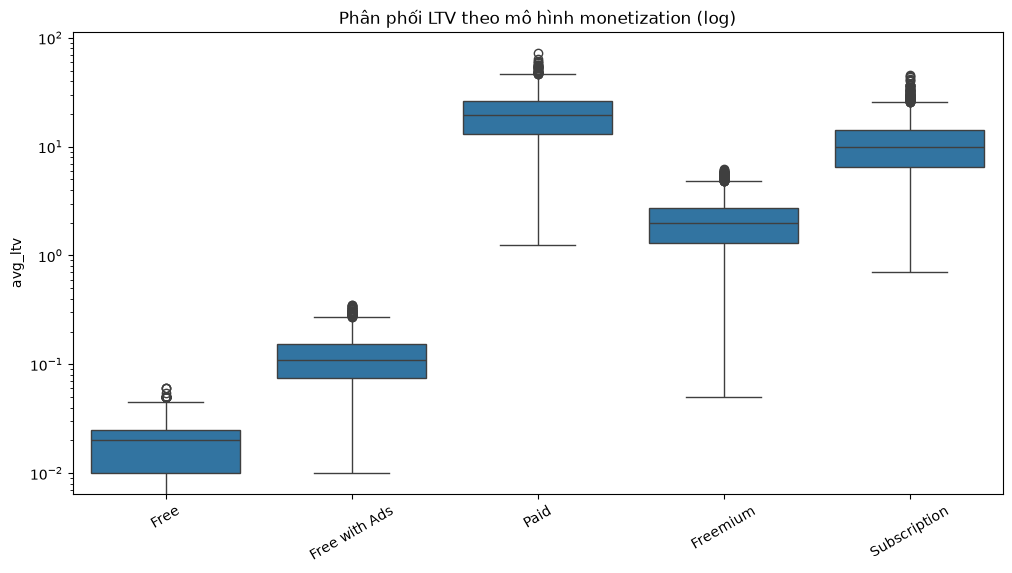

In [39]:
# 1.3. phân phối LTV

plt.figure(figsize=(12, 6))
sns.boxplot(data=gm, x='monetization_type', y='avg_ltv')
plt.yscale('log')
plt.title('Phân phối LTV theo mô hình monetization (log)')
plt.xlabel('')
plt.xticks(rotation=30)
plt.show()

LTV giữ nguyên thứ tự phân tầng như ARPU.

In [40]:
# 1.4. Các chỉ số còn khác
# eCPM và conversion rate theo mô hình (cũng SUM/SUM)
other_metrics = monet.groupby('monetization_type').apply(
    lambda x: pd.Series({
        'ecpm': x['ad_revenue_usd'].sum() / x['ad_impressions'].sum() * 1000 if x['ad_impressions'].sum() > 0 else 0,
        'avg_conversion': x['conversion_rate_pct'].mean(),
        'avg_ltv': x['ltv_usd'].mean()})).reset_index()
other_metrics

,monetization_type,ecpm,avg_conversion,avg_ltv
0,Free,0.000000,0.000000,0.018986
1,Free with Ads,18.314564,0.000000,0.116302
2,Freemium,414.171890,7.814778,2.089774
3,Paid,0.000000,0.000000,20.557688
4,Subscription,0.000000,7.801597,11.035405


Conversion rate chỉ khác 0 ở Freemium (7.81%) và Subscription (7.80%) — đúng logic ngành, vì chỉ hai mô hình này có bước chuyển đổi từ người dùng miễn phí sang trả phí.

Tuy nhiên hai giá trị này gần như bằng nhau, không đủ khác biệt để rút ra kết luận so sánh.

In [41]:
# 2. Đánh giá mô hình monetization theo quy mô lượt tải
# Cắt chéo mô hình × tier quy mô

cross = gm.groupby(['monetization_type', 'size_tier']).agg(n_games=('app_id', 'count'), median_arpu=('avg_arpu', 'median'), median_revenue=('total_revenue', 'median')).reset_index()

# xoay thành bảng 
pivot_arpu = cross.pivot(index='monetization_type', columns='size_tier', values='median_arpu')
pivot_arpu = pivot_arpu[['Long-tail', 'Mid', 'Top']]   # sắp xếp lại cột

print('ARPU trung vị theo mô hình × tier quy mô:')
pivot_arpu

ARPU trung vị theo mô hình × tier quy mô:


size_tier,Long-tail,Mid,Top
monetization_type,,,
Free,0.002529,0.002500,0.002550
Free with Ads,0.015550,0.015800,0.015600
Freemium,0.277900,0.274867,0.280600
Paid,2.616650,2.701275,2.767400
Subscription,1.443800,1.350175,1.377962


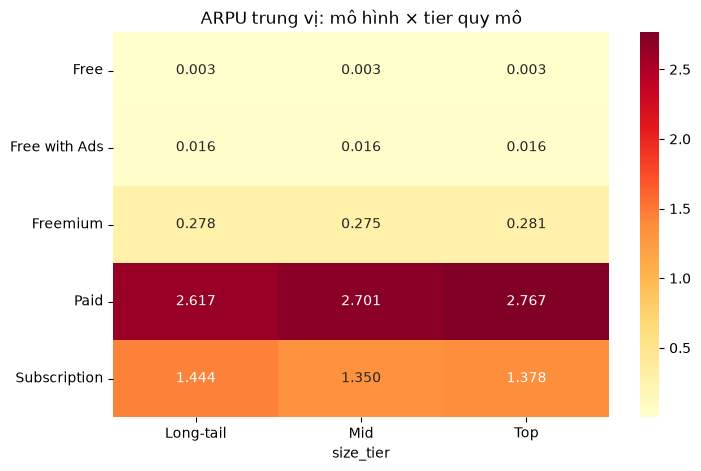

In [42]:
# vẽ heatmap cắt chéo
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_arpu, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('ARPU trung vị: mô hình × tier quy mô')
plt.ylabel('')
plt.show()

ARPU gần như không đổi giữa 3 tier quy mô trong cùng một mô hình (Freemium: 0.278/0.275/0.281).  
=> Quy mô lượt tải không ảnh hưởng đến hiệu quả kiếm tiền trên mỗi người dùng. Game nhỏ và game lớn trong cùng mô hình có ARPU tương đương, cho thấy khác biệt về doanh thu tuyệt đối đến từ số lượng người dùng, không phải từ khả năng chuyển hoá thành doanh thu.

In [43]:
# kiểm định thống kê nhằm đánh giá sự khác biệt ARPu giữa các mô hình
from scipy import stats

# tách ARPU theo từng nhóm
groups = [g['avg_arpu'].values for name, g in gm.groupby('monetization_type')]

# dùng Kruskal-Wallis thay ANOVA vì phân phối lệch mạnh (không chuẩn)
stat, pval = stats.kruskal(*groups)

print(f'Kruskal-Wallis: H = {stat:.2f}, p-value = {pval:.2f}')
if pval < 0.05:
    print('=> Có khác biệt có ý nghĩa thống kê giữa các mô hình')
else:
    print('=> Không có khác biệt có ý nghĩa')

Kruskal-Wallis: H = 13621.33, p-value = 0.00
=> Có khác biệt có ý nghĩa thống kê giữa các mô hình


In [44]:
# 3. Mở rộng: Đánh giá mô hình theo thị trường địa lý
# join để biết mỗi dòng regional thuộc mô hình nào
regional2 = regional.merge(gm[['app_id', 'monetization_type']], on='app_id', how='inner')
print(regional2.shape)
regional2.head()

(14738, 13)


,app_id,country,region_installs,avg_session_duration_minutes,avg_rating,revenue_usd,active_users,daus,maus,language,quarter,year,monetization_type
0,APP_048173,India,11,3.60,4.4,866768.81,82,31,58,pt,Q3,2026,Paid
1,APP_020256,India,21,7.47,3.5,353866.70,10,1,18,id,Q3,2026,Subscription
2,APP_047030,Argentina,125034,6.14,3.6,890802.37,65088,33809,175067,es,Q3,2024,Free
3,APP_020646,Indonesia,50574,21.04,3.7,502874.93,12111,2830,4070,ar,Q2,2026,Subscription
4,APP_029180,Russia,4106,34.36,3.9,270117.19,138,390,3103,ru,Q2,2025,Free


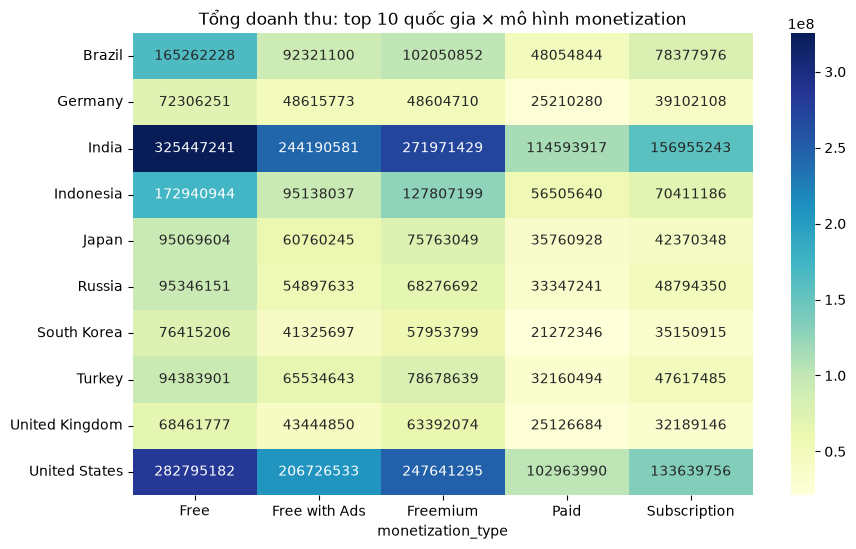

In [45]:
# top 10 quốc gia theo tổng doanh thu
top_countries = regional2.groupby('country')['revenue_usd'].sum().nlargest(10).index

reg_cross = regional2[regional2['country'].isin(top_countries)].groupby(['country', 'monetization_type'])['revenue_usd'].sum().reset_index()

pivot_reg = reg_cross.pivot(index='country', columns='monetization_type', values='revenue_usd')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_reg, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Tổng doanh thu: top 10 quốc gia × mô hình monetization')
plt.ylabel('')
plt.show()

Ấn Độ và Mỹ là hai thị trường lớn nhất, doanh thu vượt trội so với phần còn lại ở mọi mô hình.

Thứ tự đóng góp doanh thu theo mô hình không thay đổi nhiều qua các quốc gia, không có thị trường nào ưa chuộng một mô hình đặc biệt.

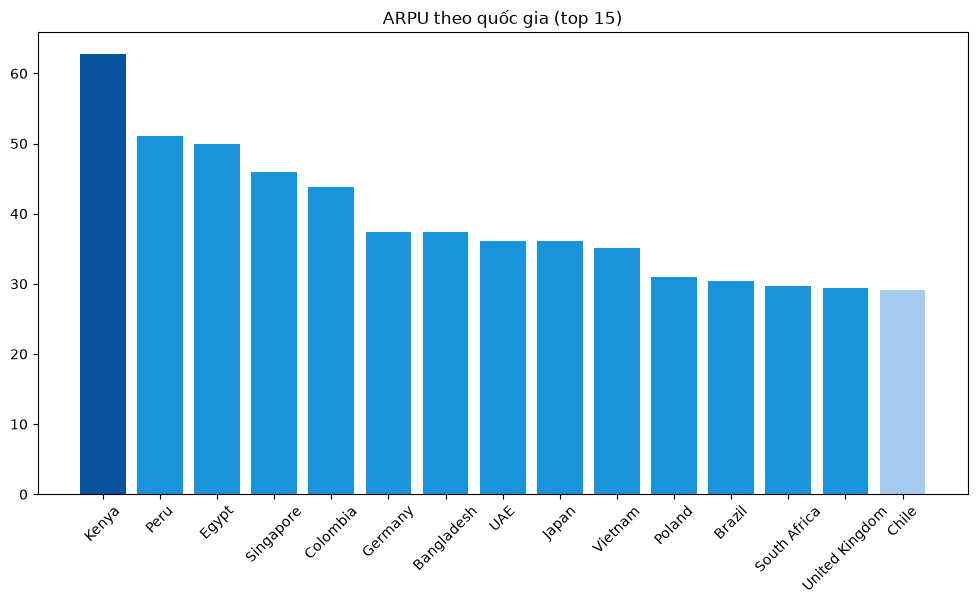

,country,total_revenue,total_users,arpu,n_games
14,Kenya,4.004242e+07,638349.0,62.728095,85.0
20,Peru,4.362151e+07,854384.0,51.056094,87.0
7,Egypt,8.537057e+07,1709420.0,49.941251,174.0
25,Singapore,4.431350e+07,964338.0,45.952244,87.0
6,Colombia,8.670074e+07,1979628.0,43.796480,173.0
9,Germany,2.667713e+08,7136695.0,37.380236,529.0
2,Bangladesh,8.506720e+07,2279487.0,37.318570,174.0
31,UAE,8.642424e+07,2391704.0,36.135006,179.0
13,Japan,3.651767e+08,10115004.0,36.102474,729.0
34,Vietnam,1.827641e+08,5211553.0,35.069025,354.0


In [46]:
# ARPU theo quốc gia (dùng active_users trong regional)

country_arpu = regional.groupby('country').apply(lambda x: pd.Series({
    'total_revenue': x['revenue_usd'].sum(),
    'total_users': x['active_users'].sum(),
    'arpu': x['revenue_usd'].sum() / x['active_users'].sum() if x['active_users'].sum() > 0 else 0,
    'n_games': x['app_id'].nunique()})).reset_index()

country_arpu = country_arpu.sort_values('arpu', ascending=False)
top15 = country_arpu.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top15['country'], top15['arpu'], color=h_color(top15['arpu']))
plt.title('ARPU theo quốc gia (top 15)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.show()

country_arpu.head(15)

Kenya, Peru, Egypt dẫn đầu về ARPU, trong khi các thị trường lớn như Japan, Brazil, United Kingdom lại thấp hơn.

Lưu ý: Các quốc gia dẫn đầu đều có rất ít game (Kenya 85, Peru 87, Singapore 87) so với Brazil (1,056) hay Japan (729). Với cỡ mẫu nhỏ, một vài game có doanh thu cao đủ để kéo lệch ARPU toàn thị trường. Kết quả này không đủ tin cậy để khuyến nghị đầu tư.

In [47]:
# 4. So sánh eCPM giữa Free with Ads và Freemium

ads = monet[monet['monetization_type'].isin(['Free with Ads', 'Freemium'])]

ad_perf = ads.groupby('monetization_type').agg(total_ad_revenue=('ad_revenue_usd', 'sum'), total_impressions=('ad_impressions', 'sum'), n_games=('app_id', 'nunique')).reset_index()

# eCPM = doanh thu quảng cáo / 1000 lượt hiển thị
ad_perf['ecpm'] = ad_perf['total_ad_revenue'] / ad_perf['total_impressions'] * 1000

ad_perf

,monetization_type,total_ad_revenue,total_impressions,n_games,ecpm
0,Free with Ads,4.170955e+07,2277397905,2953,18.314564
1,Freemium,1.654058e+09,3993652207,3735,414.171890


Nhận xét: eCPM của Freemium (322–415) cao gấp khoảng 20 lần Free with Ads (18–19), và tăng theo quy mô game. Đây là khác biệt rõ nhất tìm được trong phân tích quảng cáo.

# PHẦN 3: EDA2 - ĐÁNH GIÁ CỤ THỂ MỘT SỐ MÔ HÌNH MONET

Câu hỏi: Sau khi chọn được mô hình, nên thiết kế sản phẩm như thế nào hay bán loại vật phẩm nào, chia gói thuê bao ra sao?

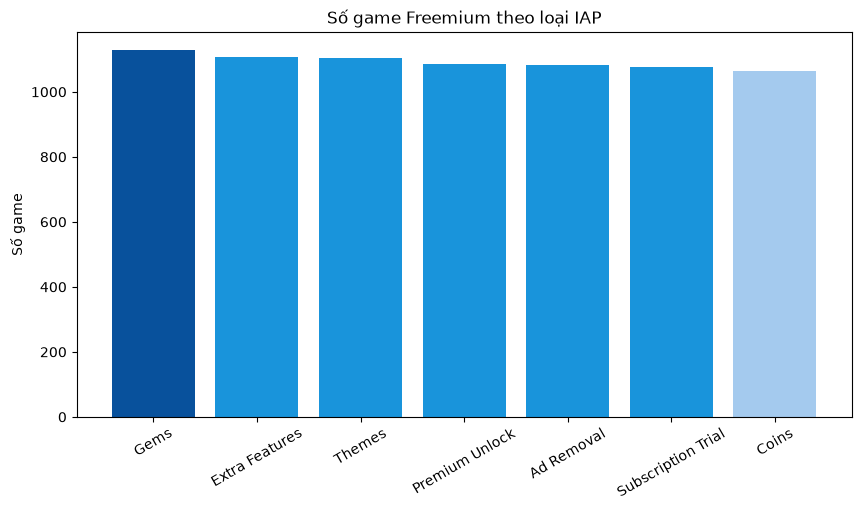

,iap_category,n_records,n_games,share_pct
3,Gems,1288,1128,14.750883
2,Extra Features,1272,1106,14.463188
6,Themes,1278,1103,14.423957
4,Premium Unlock,1251,1086,14.201648
0,Ad Removal,1258,1083,14.162417
5,Subscription Trial,1250,1077,14.083954
1,Coins,1221,1064,13.913953


In [48]:
# ============================================
# PHẦN 3: EDA2 - ĐÁNH GIÁ CỤ THỂ MỘT SỐ MÔ HÌNH MONET
# ============================================

# 1. Freemium
# 1.1. Phân bố iap_category
freemium = monet[monet['monetization_type'] == 'Freemium']

iap_mix = freemium.groupby('iap_category').agg(n_records=('app_id', 'count'), n_games=('app_id', 'nunique')).reset_index().sort_values('n_games', ascending=False)

iap_mix['share_pct'] = iap_mix['n_games'] / iap_mix['n_games'].sum() * 100

plt.figure(figsize=(10, 5))
plt.bar(iap_mix['iap_category'], iap_mix['n_games'], color=h_color(iap_mix['n_games']))
plt.title('Số game Freemium theo loại IAP')
plt.ylabel('Số game')
plt.xticks(rotation=30)
plt.show()

iap_mix

Các loại IAP phân bố gần như đều nhau, từ 13.9% (Coins) đến 14.75% (Gems).  
=> Không có loại vật phẩm nào chiếm ưu thế trong danh mục game Freemium. Không đủ cơ sở để khuyến nghị ưu tiên một loại IAP cụ thể khi thiết kế sản phẩm.

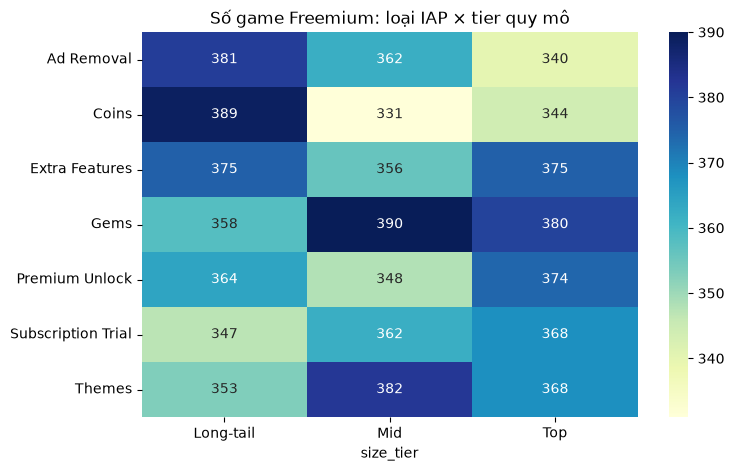

In [49]:
# 1.2. IAP × tier quy mô
freemium_tier = freemium.merge(gm[['app_id', 'size_tier']], on='app_id', how='inner')

iap_tier = freemium_tier.groupby(['iap_category', 'size_tier'])['app_id'].nunique().reset_index()
pivot_iap = iap_tier.pivot(index='iap_category', columns='size_tier', values='app_id')
pivot_iap = pivot_iap[['Long-tail', 'Mid', 'Top']]

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_iap, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Số game Freemium: loại IAP × tier quy mô')
plt.ylabel('')
plt.show()

Số game dao động từ 331 đến 390 ở mọi ô, quanh mức kỳ vọng nếu phân bố hoàn toàn đều (~355).
Game ở các quy mô khác nhau không có xu hướng chọn loại IAP khác nhau.

In [50]:
# 2. Subscription 
# deep-dive theo tier

sub = monet[monet['monetization_type'] == 'Subscription']

sub_tier = sub.groupby('subscription_tier').agg(
    n_games=('app_id', 'nunique'),
    total_revenue=('total_revenue_usd', 'sum'),
    total_sub_users=('subscription_active_users', 'sum'),
    avg_arpu=('arpu_usd', 'mean'),
    avg_ltv=('ltv_usd', 'mean')
).reset_index()

# ARPU
sub2 = sub[sub['arpu_usd'] > 0].copy()
sub2['user_base'] = sub2['total_revenue_usd'] / sub2['arpu_usd']
arpu_tier = sub2.groupby('subscription_tier').apply(lambda x: x['total_revenue_usd'].sum() / x['user_base'].sum()).reset_index(name='arpu_weighted')

sub_tier = sub_tier.merge(arpu_tier, on='subscription_tier')
sub_tier

,subscription_tier,n_games,total_revenue,total_sub_users,avg_arpu,avg_ltv,arpu_weighted
0,Basic,1049,2.350901e+09,51125832,1.497244,11.237209,1.437700
1,Enterprise,982,2.109565e+09,35657106,1.467082,10.786849,1.699704
2,Premium,991,5.455109e+09,69584244,1.483005,10.935248,1.586393
3,Standard,995,3.574812e+09,54000704,1.504167,11.169496,1.799150


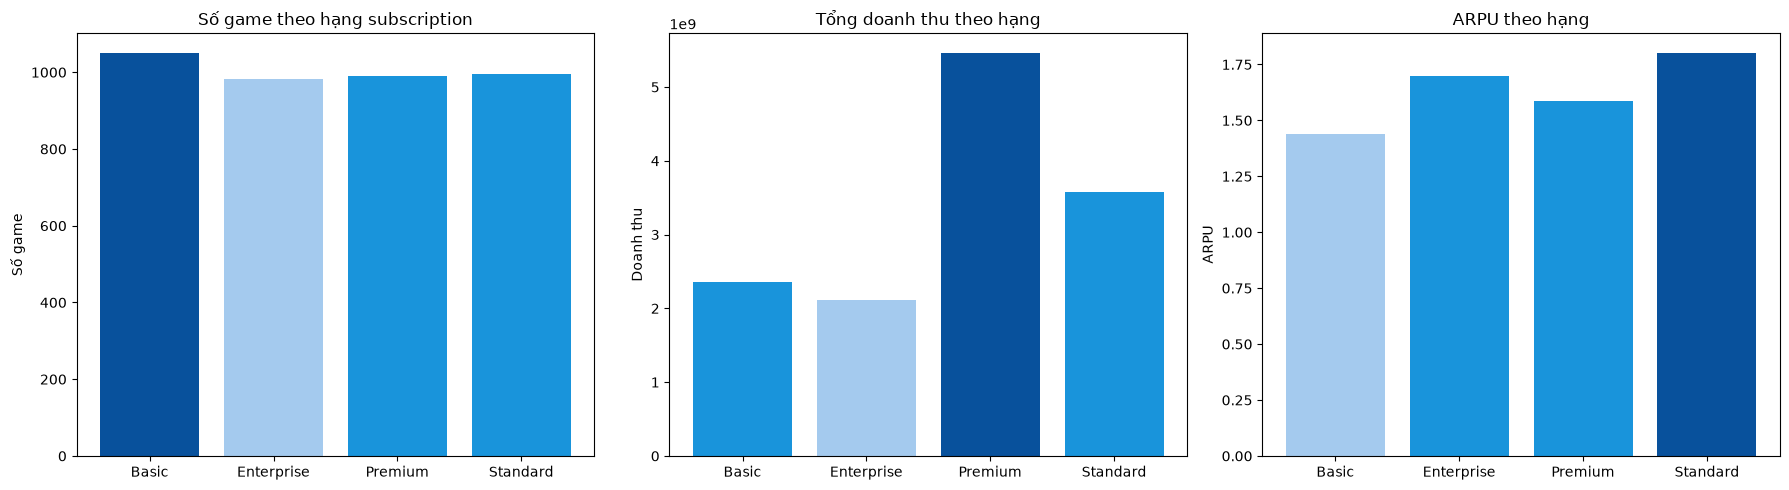

In [51]:
# Visualization so sánh subscription tier

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(sub_tier['subscription_tier'], sub_tier['n_games'], color=h_color(sub_tier['n_games']))
axes[0].set_title('Số game theo hạng subscription')
axes[0].set_ylabel('Số game')

axes[1].bar(sub_tier['subscription_tier'], sub_tier['total_revenue'], color=h_color(sub_tier['total_revenue']))
axes[1].set_title('Tổng doanh thu theo hạng')
axes[1].set_ylabel('Doanh thu')

axes[2].bar(sub_tier['subscription_tier'], sub_tier['arpu_weighted'], color=h_color(sub_tier['arpu_weighted']))
axes[2].set_title('ARPU theo hạng')
axes[2].set_ylabel('ARPU')

plt.tight_layout()
plt.show()

Bốn hạng thuê bao có số lượng game tương đương (982–1,049 game). Trong đó, ARPU giữa các hạng không theo thứ tự kỳ vọng với Standard (1.80) cao hơn Premium (1.59) và Enterprise (1.70). Về mặt kinh doanh, gói cao cấp hơn thường mang lại doanh thu trên mỗi người dùng cao hơn, nhưng dữ liệu không phản ánh điều đó.  
=> Không có bằng chứng cho thấy hạng thuê bao cao hơn hiệu quả hơn. Riêng tổng doanh thu, Premium dẫn đầu (5.46 tỷ) chủ yếu do có nhiều người dùng thuê bao hơn, không phải do ARPU cao hơn.

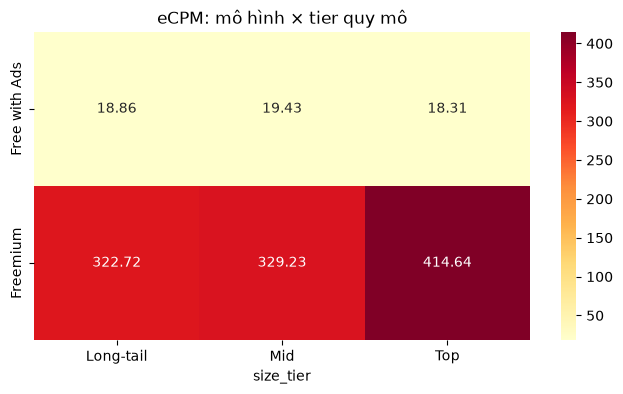

size_tier,Long-tail,Mid,Top
monetization_type,,,
Free with Ads,18.857302,19.434784,18.306485
Freemium,322.719945,329.234954,414.640533


In [52]:
# 3. Free with Ads
# eCPM theo tier quy mô

ads_tier = ads.merge(gm[['app_id', 'size_tier']], on='app_id', how='inner')

ecpm_tier = ads_tier.groupby(['monetization_type', 'size_tier']).apply(
    lambda x: x['ad_revenue_usd'].sum() / x['ad_impressions'].sum() * 1000 if x['ad_impressions'].sum() > 0 else 0).reset_index(name='ecpm')

pivot_ecpm = ecpm_tier.pivot(index='monetization_type', columns='size_tier', values='ecpm')
pivot_ecpm = pivot_ecpm[['Long-tail', 'Mid', 'Top']]

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_ecpm, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('eCPM: mô hình × tier quy mô')
plt.ylabel('')
plt.show()

pivot_ecpm

Khác biệt eCPM giữa hai mô hình rất lớn và ổn định qua cả ba tier. Riêng trong nhóm Freemium, eCPM tăng theo quy mô: Long-tail (322) => Mid (329) => Top (415).  
=> Đây là xu hướng theo quy mô rõ ràng nhất tìm được trong toàn bộ phân tích. Điều này cũng trái ngược với ARPU vốn không đổi theo tier.

# TỔNG KẾT

Phát hiện chính:
1. Mô hình thu tiền trực tiếp (Paid, Subscription) chiếm 24.7% số game nhưng tạo 83% doanh thu thị trường.

2. ARPU và LTV phân tầng rõ rệt theo mô hình, chênh lệch trên 1,000 lần giữa Paid và Free.

3. Quy mô lượt tải không ảnh hưởng đến ARPU — game nhỏ và lớn trong cùng mô hình monetize hiệu quả như nhau.

4. eCPM của Freemium cao gấp 23 lần Free with Ads, và là chỉ số duy nhất tăng theo quy mô game.

5. Không có khác biệt đáng kể giữa các loại IAP hay các hạng thuê bao.

Hạn chế: Dữ liệu là synthetic, nên các kết luận phản ánh cách sinh dữ liệu chứ không phải quy luật thị trường thực tế. Chi tiết xem phần Known Limitations trong báo cáo.